# Deteksi Support & Resistance BBCA dengan K-Means Clustering

**Ide:** harga-harga *swing* (pivot high / pivot low) yang berdekatan dikelompokkan oleh K-Means.
Centroid tiap cluster = level support/resistance.
Level di bawah harga terakhir dilabeli **SUPPORT**, di atasnya **RESISTANCE**.

Jumlah cluster dipilih otomatis lewat **elbow method** (kneedle) dan dibandingkan
terhadap **silhouette score**.

Saham: `BBCA.JK` | Periode: Juli 2025 – Juni 2026 | Sumber data: yfinance

## 0. Install dependency (jalankan sekali saja)

In [ ]:
# %pip install yfinance scikit-learn pandas matplotlib

## 1. Import & parameter

In [ ]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

TICKER = "BBCA.JK"
START = "2025-07-01"
END = "2026-06-30"
PIVOT_WINDOW = 5      # bar kiri/kanan untuk konfirmasi swing point
K_RANGE = range(2, 16)

## 2. Ambil data dari yfinance

In [ ]:
df = yf.download(TICKER, start=START, end=END, auto_adjust=False, progress=False)
if isinstance(df.columns, pd.MultiIndex):
    df.columns = df.columns.get_level_values(0)
df = df.dropna()

print(f"Data: {len(df)} bar, {df.index[0].date()} s/d {df.index[-1].date()}")
df.tail()

Data: 242 bar, 2025-07-01 s/d 2026-06-29


Price,Adj Close,Close,High,Low,Open,Volume
Date,,,,,,
2026-06-23,6125.0,6125.0,6200.0,6075.0,6150.0,144561900
2026-06-24,5925.0,5925.0,6200.0,5925.0,6125.0,144928800
2026-06-25,6025.0,6025.0,6175.0,5900.0,5900.0,197935000
2026-06-26,6175.0,6175.0,6175.0,6025.0,6050.0,163378700
2026-06-29,5925.0,5925.0,6200.0,5925.0,6175.0,189886600


## 3. Deteksi swing point (pivot high / pivot low)

Swing high = `High` tertinggi dalam jendela ±`PIVOT_WINDOW` bar. Sebaliknya untuk swing low.
Yang di-cluster adalah titik-titik ini, bukan seluruh harga close — supaya level yang muncul
memang harga yang pernah ditolak pasar.

In [ ]:
def find_pivots(df, w=PIVOT_WINDOW):
    high, low = df["High"], df["Low"]
    roll_max = high.rolling(2 * w + 1, center=True).max()
    roll_min = low.rolling(2 * w + 1, center=True).min()

    pivot_high = df.index[(high == roll_max) & roll_max.notna()]
    pivot_low = df.index[(low == roll_min) & roll_min.notna()]

    points = pd.concat([
        pd.DataFrame({"date": pivot_high, "price": high[pivot_high].values, "type": "high"}),
        pd.DataFrame({"date": pivot_low, "price": low[pivot_low].values, "type": "low"}),
    ], ignore_index=True)
    return points.sort_values("date").reset_index(drop=True)


points = find_pivots(df)
print(f"Swing points terdeteksi: {len(points)}")
points.head(10)

Swing points terdeteksi: 40


,date,price,type
0,2025-07-08,8425.0,low
1,2025-07-14,8675.0,high
2,2025-07-21,8375.0,low
3,2025-07-28,8625.0,high
4,2025-07-31,8250.0,low
5,2025-08-13,8975.0,high
6,2025-09-09,7475.0,low
7,2025-09-15,8100.0,high
8,2025-09-18,7650.0,low
9,2025-09-24,7950.0,high


## 4. Menentukan jumlah cluster (k)

Dua metode dipakai berdampingan:

- **Elbow method** — plot *inertia* (WCSS, jumlah jarak kuadrat ke centroid) terhadap k.
  Titik "siku" dideteksi otomatis pakai metode **kneedle**: tarik garis lurus dari titik
  pertama ke titik terakhir kurva, lalu cari k dengan jarak tegak lurus terbesar ke garis itu.
- **Silhouette score** — seberapa rapat anggota cluster vs jaraknya ke cluster tetangga.

Keduanya sering tidak sepakat. Untuk data 1-D seperti harga, silhouette cenderung
naik terus seiring k (tiap titik makin gampang jadi cluster sendiri), jadi elbow lebih
bisa diandalkan untuk membatasi jumlah level agar tetap masuk akal dibaca.

In [ ]:
def evaluate_k(prices, k_range=K_RANGE):
    """Hitung inertia (elbow) dan silhouette untuk tiap k."""
    X = prices.reshape(-1, 1)
    rows = []
    for k in k_range:
        if k >= len(X):
            break
        km = KMeans(n_clusters=k, n_init=10, random_state=42).fit(X)
        rows.append({
            "k": k,
            "inertia": km.inertia_,
            "silhouette": silhouette_score(X, km.labels_) if k >= 2 else np.nan,
        })
    return pd.DataFrame(rows).set_index("k")


def elbow_k(inertia: pd.Series) -> int:
    """Deteksi siku dengan metode kneedle (jarak tegak lurus terjauh ke garis ujung-ke-ujung)."""
    k = inertia.index.values.astype(float)
    y = inertia.values.astype(float)

    # normalisasi ke [0,1] agar sumbu k dan inertia sebanding
    kn = (k - k.min()) / (k.max() - k.min())
    yn = (y - y.min()) / (y.max() - y.min())

    # garis lurus dari titik pertama ke titik terakhir kurva
    x1, y1, x2, y2 = kn[0], yn[0], kn[-1], yn[-1]
    dist = np.abs((y2 - y1) * kn - (x2 - x1) * yn + x2 * y1 - y2 * x1) / np.hypot(y2 - y1, x2 - x1)
    return int(k[dist.argmax()])


evalu = evaluate_k(points["price"].values)
k_elbow = elbow_k(evalu["inertia"])
k_silhouette = int(evalu["silhouette"].idxmax())

print(f"k dari elbow method : {k_elbow}")
print(f"k dari silhouette   : {k_silhouette}")
evalu.assign(inertia=lambda d: d["inertia"].map("{:,.0f}".format),
             silhouette=lambda d: d["silhouette"].round(3))

k dari elbow method : 5
k dari silhouette   : 12


,inertia,silhouette
k,,
2,"10,216,077",0.627
3,"5,487,342",0.547
4,"3,173,587",0.547
5,"1,822,827",0.542
6,"1,224,365",0.578
7,"744,374",0.605
8,"446,223",0.637
9,"348,583",0.627
10,"252,583",0.652


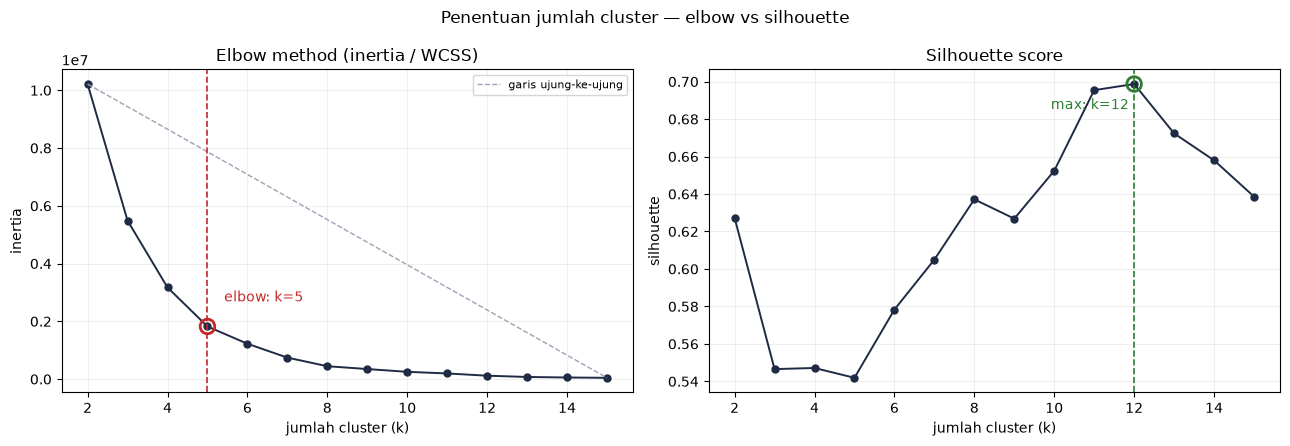

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))

# --- Elbow ---
ax1.plot(evalu.index, evalu["inertia"], "o-", color="#1f2a44", lw=1.4, ms=5)
ax1.plot([evalu.index[0], evalu.index[-1]],
         [evalu["inertia"].iloc[0], evalu["inertia"].iloc[-1]],
         "--", color="#9aa3b2", lw=1, label="garis ujung-ke-ujung")
ax1.axvline(k_elbow, color="#c62828", ls="--", lw=1.2)
ax1.scatter([k_elbow], [evalu.loc[k_elbow, "inertia"]], s=110, facecolor="none",
            edgecolor="#c62828", lw=2, zorder=3)
ax1.annotate(f"elbow: k={k_elbow}", (k_elbow, evalu.loc[k_elbow, "inertia"]),
             textcoords="offset points", xytext=(12, 18), color="#c62828", fontsize=10)
ax1.set_title("Elbow method (inertia / WCSS)")
ax1.set_xlabel("jumlah cluster (k)"); ax1.set_ylabel("inertia")
ax1.legend(fontsize=8); ax1.grid(alpha=0.2)

# --- Silhouette ---
ax2.plot(evalu.index, evalu["silhouette"], "o-", color="#1f2a44", lw=1.4, ms=5)
ax2.axvline(k_silhouette, color="#2e7d32", ls="--", lw=1.2)
ax2.scatter([k_silhouette], [evalu.loc[k_silhouette, "silhouette"]], s=110, facecolor="none",
            edgecolor="#2e7d32", lw=2, zorder=3)
ax2.annotate(f"max: k={k_silhouette}", (k_silhouette, evalu.loc[k_silhouette, "silhouette"]),
             textcoords="offset points", xytext=(-60, -18), color="#2e7d32", fontsize=10)
ax2.set_title("Silhouette score")
ax2.set_xlabel("jumlah cluster (k)"); ax2.set_ylabel("silhouette")
ax2.grid(alpha=0.2)

fig.suptitle("Penentuan jumlah cluster — elbow vs silhouette", fontsize=12)
fig.tight_layout()
plt.show()

### Keputusan k

`K_METHOD` menentukan mana yang dipakai:

- `"elbow"` — pakai siku kurva inertia (default; jumlah level lebih ringkas & terbaca)
- `"silhouette"` — pakai silhouette tertinggi
- angka, misal `K_METHOD = 8` — override manual kalau mau jumlah level tertentu

In [ ]:
K_METHOD = "elbow"   # "elbow" | "silhouette" | int

if isinstance(K_METHOD, int):
    k = K_METHOD
elif K_METHOD == "silhouette":
    k = k_silhouette
else:
    k = k_elbow

print(f"K dipakai: {k}  (metode: {K_METHOD})")

K dipakai: 5  (metode: elbow)


## 5. Clustering → level support & resistance

In [ ]:
X = points["price"].values.reshape(-1, 1)
km = KMeans(n_clusters=k, n_init=10, random_state=42).fit(X)
points = points.assign(cluster=km.labels_)

levels = (
    points.groupby("cluster")["price"]
    .agg(level="mean", n_touch="size", low="min", high="max")
    .sort_values("level")
    .reset_index(drop=True)
)

last_price = float(df["Close"].iloc[-1])
levels["zona"] = np.where(levels["level"] < last_price, "SUPPORT", "RESISTANCE")
levels["jarak_%"] = (levels["level"] / last_price - 1) * 100

print(f"Harga terakhir: {last_price:,.0f}\n")
levels

Harga terakhir: 5,925



,level,n_touch,low,high,zona,jarak_%
0,4820.000000,1,4820.0,4820.0,SUPPORT,-18.649789
1,6243.750000,8,5800.0,6550.0,RESISTANCE,5.379747
2,7187.500000,8,6825.0,7475.0,RESISTANCE,21.308017
3,8001.923077,13,7650.0,8250.0,RESISTANCE,35.053554
4,8582.500000,10,8325.0,8975.0,RESISTANCE,44.852321


## 6. Visualisasi

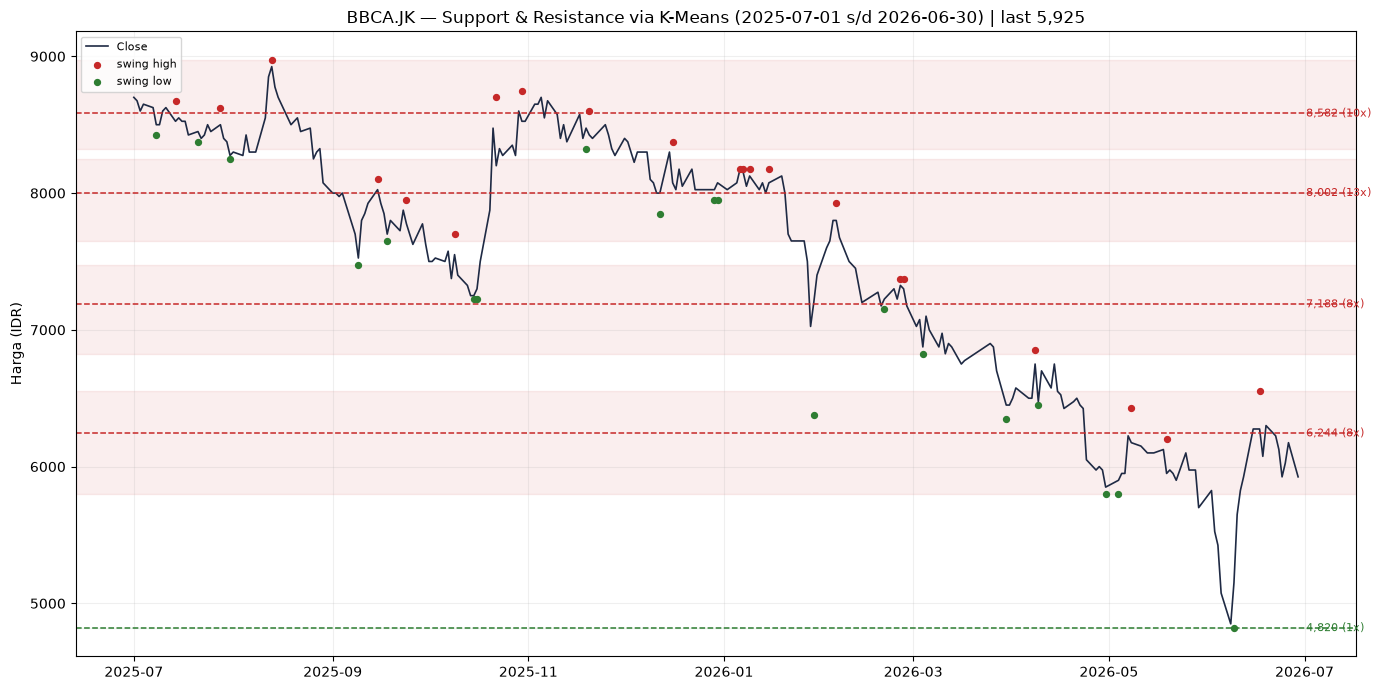

In [ ]:
fig, ax = plt.subplots(figsize=(14, 7))
ax.plot(df.index, df["Close"], color="#1f2a44", lw=1.2, label="Close")

for _, r in levels.iterrows():
    color = "#2e7d32" if r.zona == "SUPPORT" else "#c62828"
    ax.axhspan(r.low, r.high, color=color, alpha=0.08)
    ax.axhline(r.level, color=color, ls="--", lw=1.1)
    ax.text(df.index[-1], r.level, f"  {r.level:,.0f} ({int(r.n_touch)}x)",
            va="center", fontsize=8, color=color)

hi = points[points.type == "high"]
lo = points[points.type == "low"]
ax.scatter(hi.date, hi.price, s=18, color="#c62828", zorder=3, label="swing high")
ax.scatter(lo.date, lo.price, s=18, color="#2e7d32", zorder=3, label="swing low")

ax.set_title(f"BBCA.JK — Support & Resistance via K-Means "
             f"({START} s/d {END}) | last {last_price:,.0f}")
ax.set_ylabel("Harga (IDR)")
ax.legend(loc="upper left", fontsize=8)
ax.grid(alpha=0.2)
fig.tight_layout()
plt.show()

## Catatan interpretasi

BBCA turun tajam sepanjang periode ini (±8.700 → ±5.900), jadi mayoritas level berada **di atas**
harga sekarang. Itu wajar — hampir semua swing point terbentuk saat harga masih tinggi.

Konsekuensinya sisi support tipis. Perhatikan kolom `n_touch`: level dengan 1–2 sentuhan
jauh lebih lemah daripada yang 5–6 sentuhan, jangan diperlakukan setara.

Parameter yang bisa di-tuning:
- `PIVOT_WINDOW` — kecilkan ke 3 untuk swing point lebih banyak & level lebih rapat
- `K_METHOD` — `"elbow"`, `"silhouette"`, atau angka untuk override manual
- `K_RANGE` — rentang k yang diuji; kalau siku jatuh persis di ujung rentang, perlebar

In [ ]:
import numpy as np
import pandas as pd
import yfinance as yf
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.utils import compute_class_weight

# Try to import TensorFlow; if unavailable, fall back to a sklearn classifier
USE_TF = True
try:
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import LSTM, Dense, Dropout
    from tensorflow.keras.callbacks import EarlyStopping
except Exception:
    USE_TF = False
    from sklearn.ensemble import RandomForestClassifier


TICKER = "BBCA.JK"
START = "2025-07-01"
END = "2026-06-30"
PIVOT_WINDOW = 5
K_RANGE = range(2, 16)
LOOKBACK = 20
FUTURE_DAYS = 1
ZONE_TOLERANCE = 0.0  # level zone already has low/high from pivots


def find_pivots(df, w=PIVOT_WINDOW):
    high, low = df["High"], df["Low"]
    roll_max = high.rolling(2 * w + 1, center=True).max()
    roll_min = low.rolling(2 * w + 1, center=True).min()

    pivot_high = df.index[(high == roll_max) & roll_max.notna()]
    pivot_low = df.index[(low == roll_min) & roll_min.notna()]

    points = pd.concat([
        pd.DataFrame({"date": pivot_high, "price": high.loc[pivot_high].values, "type": "high"}),
        pd.DataFrame({"date": pivot_low, "price": low.loc[pivot_low].values, "type": "low"}),
    ], ignore_index=True)
    return points.sort_values("date").reset_index(drop=True)


def evaluate_k(prices, k_range=K_RANGE):
    X = prices.reshape(-1, 1)
    rows = []
    for k in k_range:
        if k >= len(X):
            break
        km = KMeans(n_clusters=k, n_init=10, random_state=42).fit(X)
        rows.append({
            "k": k,
            "inertia": km.inertia_,
            "silhouette": silhouette_score(X, km.labels_) if k >= 2 else np.nan,
        })
    return pd.DataFrame(rows).set_index("k")


def elbow_k(inertia: pd.Series) -> int:
    k = inertia.index.values.astype(float)
    y = inertia.values.astype(float)
    kn = (k - k.min()) / (k.max() - k.min())
    yn = (y - y.min()) / (y.max() - y.min())
    x1, y1, x2, y2 = kn[0], yn[0], kn[-1], yn[-1]
    dist = np.abs((y2 - y1) * kn - (x2 - x1) * yn + x2 * y1 - y2 * x1) / np.hypot(y2 - y1, x2 - x1)
    return int(k[dist.argmax()])


def build_lstm(input_shape):
    model = Sequential()
    model.add(LSTM(64, input_shape=input_shape, return_sequences=False))
    model.add(Dropout(0.2))
    model.add(Dense(32, activation="relu"))
    model.add(Dropout(0.1))
    model.add(Dense(1, activation="sigmoid"))
    model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"]) 
    return model


def prepare_sequences(X, y, lookback=LOOKBACK):
    seq_X, seq_y = [], []
    for i in range(len(X) - lookback - FUTURE_DAYS + 1):
        seq_X.append(X[i : i + lookback])
        seq_y.append(y[i + lookback - 1])
    return np.array(seq_X), np.array(seq_y)


def main():
    df = yf.download(TICKER, start=START, end=END, auto_adjust=False, progress=False)
    # Jika yfinance mengembalikan MultiIndex (mis. beberapa ticker), ambil level nama kolom saja
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)
    df = df.dropna()
    print(f"Loaded {len(df)} rows")

    points = find_pivots(df)
    if points.empty:
        raise SystemExit("No pivot points found; adjust PIVOT_WINDOW or date range")

    evalu = evaluate_k(points["price"].values)
    k_elbow = elbow_k(evalu["inertia"]) if not evalu.empty else 3
    k = k_elbow
    print(f"Using k={k} (elbow)")

    Xp = points["price"].values.reshape(-1, 1)
    km = KMeans(n_clusters=k, n_init=10, random_state=42).fit(Xp)
    points = points.assign(cluster=km.labels_)
    levels = (
        points.groupby("cluster")["price"]
        .agg(level="mean", n_touch="size", low="min", high="max")
        .sort_values("level")
        .reset_index(drop=True)
    )

    last_price = float(df["Close"].iloc[-1])
    levels["zona"] = np.where(levels["level"] < last_price, "SUPPORT", "RESISTANCE")

    # Label each day with zone if close within cluster's low-high range
    def zone_for_price(p):
        hits = levels[(levels["low"] - 1e-9 <= p) & (p <= levels["high"] + 1e-9)]
        if len(hits):
            # if multiple, pick nearest level
            idx = (hits["level"].sub(p).abs()).idxmin()
            return hits.loc[idx, "zona"]
        return "NONE"

    df = df.assign(zone=df["Close"].apply(zone_for_price))

    # Create directional target: next day close > today close -> 1 else 0
    df["future_close"] = df["Close"].shift(-FUTURE_DAYS)
    df["target"] = (df["future_close"] > df["Close"]).astype(int)
    df = df.dropna(subset=["future_close"]).copy()

    # Features: log returns, MA5, MA10, Volume, zone one-hot
    df["ret"] = np.log(df["Close"]).diff().fillna(0)
    df["ma5"] = df["Close"].rolling(5).mean().fillna(method="bfill")
    df["ma10"] = df["Close"].rolling(10).mean().fillna(method="bfill")

    zones = pd.get_dummies(df["zone"].astype(str)).reindex(columns=["NONE", "SUPPORT", "RESISTANCE"], fill_value=0)
    feats = pd.concat([
        df[["ret", "ma5", "ma10", "Volume" ]].reset_index(drop=True),
        zones.reset_index(drop=True),
    ], axis=1)

    # Ensure all features are numeric (avoid pandas.array DataFrame error on some Colab pandas versions)
    feats = feats.apply(pd.to_numeric, errors="coerce").fillna(0)

    scaler = MinMaxScaler()
    Xs = scaler.fit_transform(feats.values)
    ys = df["target"].values

    X_seq, y_seq = prepare_sequences(Xs, ys)
    if len(X_seq) == 0:
        raise SystemExit("Not enough data for the chosen LOOKBACK")

    X_train, X_test, y_train, y_test = train_test_split(X_seq, y_seq, test_size=0.2, random_state=42, shuffle=False)
    print("Shapes", X_train.shape, X_test.shape)

    # Diagnostic: class distribution
    unique, counts = np.unique(y_train, return_counts=True)
    dist = dict(zip(unique.tolist(), counts.tolist()))
    pos_ratio = y_train.mean() if len(y_train) else 0.0
    print("Train target distribution:", dist)
    print(f"Train positive ratio: {pos_ratio:.3f}")

    # Compute class weights to mitigate imbalance
    classes = np.unique(y_train)
    if len(classes) > 1:
        cw = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
        class_weight = {int(c): float(w) for c, w in zip(classes, cw)}
        print("Using class_weight:", class_weight)
    else:
        class_weight = None

    if USE_TF:
        model = build_lstm(input_shape=(X_train.shape[1], X_train.shape[2]))
        es = EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True)
        fit_kwargs = dict(validation_data=(X_test, y_test), epochs=80, batch_size=16, callbacks=[es], verbose=2)
        if class_weight is not None:
            fit_kwargs['class_weight'] = class_weight
        model.fit(X_train, y_train, **fit_kwargs)
        loss, acc = model.evaluate(X_test, y_test, verbose=0)
        print(f"Test loss={loss:.4f}, acc={acc:.4f}")
        probs = model.predict(X_test).reshape(-1)
        print("Sample probabilities:", np.round(probs[:20], 4))
        preds = (probs > 0.5).astype(int)
        print("Sample predictions:", preds[:20])
        model.save("bbca_lstm_model.h5")
        print("Model saved to bbca_lstm_model.h5")
    else:
        # Flatten sequences for sklearn classifier
        nsamples, nt, nf = X_train.shape
        X_train_flat = X_train.reshape((nsamples, nt * nf))
        X_test_flat = X_test.reshape((X_test.shape[0], nt * nf))
        if class_weight is not None:
            clf = RandomForestClassifier(n_estimators=200, random_state=42, class_weight='balanced')
        else:
            clf = RandomForestClassifier(n_estimators=200, random_state=42)
        clf.fit(X_train_flat, y_train)
        acc = clf.score(X_test_flat, y_test)
        print(f"RandomForest test accuracy: {acc:.4f} (TensorFlow not available)")
        if hasattr(clf, 'predict_proba'):
            probs = clf.predict_proba(X_test_flat)[:, 1]
            print("Sample probabilities:", np.round(probs[:20], 4))
            preds = (probs > 0.5).astype(int)
        else:
            preds = clf.predict(X_test_flat)
        print("Sample predictions:", preds[:20])


if __name__ == "__main__":
    main()